# Exploratory Data Analysis

We want to analyze the data and highlight some simple patterns that matter for modelling using LightGBM, Neural Networks and other advanced models. We might ask some questions about the data:

- Are there many NaN values?
- Which is the data distribution?

In [28]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/cubagem_40k_amazon.csv")
df.columns

Index(['asin', 'title', 'main_category', 'source_category', 'categories',
       'store', 'length_cm', 'width_cm', 'height_cm', 'weight_g', 'volume_cm3',
       'density_g_cm3', 'log_volume', 'log_weight', 'dim_max_cm', 'dim_min_cm',
       'dim_ratio', 'price_raw', 'price_numeric', 'log_price', 'avg_rating',
       'n_ratings', 'n_images', 'title_length', 'title_word_count',
       'has_dim_in_title', 'has_size_word_in_title', 'has_qty_in_title',
       'description', 'description_length', 'n_categories_levels', 'image_url',
       'split'],
      dtype='str')

In [3]:
features = {
    "categorical": [
        "main_category",
        "source_category",
        "categories",
        "store",
    ],
    "text": [
        "title",
        "description",
    ],
    "numerical": [
        "price_numeric",
        "avg_rating",
        "n_ratings",
        "n_images",
        "title_length",
        "title_word_count",
        "description_length",
        "n_categories_levels",
    ],
    "title_regex": [
        "has_dim_in_title",
        "has_size_word_in_title",
        "has_qty_in_title",
    ],
    "image": [
        "image_url",
    ],
}

targets = [
    "length_cm",   # length >= width >= height
    "width_cm",
    "height_cm",
    "weight_g",
    "volume_cm3",  # derived: length_cm * width_cm * height_cm
]

## Dataset Descriptions

In [4]:
df[features["numerical"]].describe()

,price_numeric,avg_rating,n_ratings,n_images,title_length,title_word_count,description_length,n_categories_levels
count,20459.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000
mean,38.895760,4.236365,537.669025,4.993925,112.87230,17.704225,297.305200,4.036600
std,80.286958,0.633111,3933.750320,2.761300,54.41841,8.603188,360.288383,1.407039
min,0.010000,1.000000,1.000000,0.000000,5.00000,1.000000,0.000000,0.000000
25%,11.990000,4.000000,8.000000,2.000000,65.00000,10.000000,0.000000,4.000000
50%,19.990000,4.400000,34.000000,6.000000,109.00000,17.000000,123.000000,4.000000
75%,35.990000,4.600000,164.000000,7.000000,162.00000,25.000000,539.000000,5.000000
max,2999.000000,5.000000,369516.000000,26.000000,742.00000,106.000000,1000.000000,9.000000


In [5]:
df[features["title_regex"]].describe()

,has_dim_in_title,has_size_word_in_title,has_qty_in_title
count,40000,40000,40000
unique,2,2,2
top,False,False,False
freq,31648,32807,32236


In [6]:
df[features["categorical"]].describe()

,main_category,source_category,categories,store
count,40000,40000,37302,39468
unique,44,7,4406,25613
top,Amazon Home,Home_and_Kitchen,Toys & Games > Preschool > Pre-Kindergarten Toys,Generic
freq,8704,7825,339,113


In [7]:
df[targets].describe()

,length_cm,width_cm,height_cm,weight_g,volume_cm3
count,40000.000000,40000.000000,40000.000000,40000.000000,4.000000e+04
mean,28.256961,17.775909,7.362241,951.254973,1.091487e+04
std,22.769196,13.889379,7.802568,2873.314349,6.355813e+04
min,1.270000,0.510000,0.510000,1.000000,1.298432e+00
25%,15.240000,8.990000,2.540000,96.390000,4.777763e+02
50%,22.860000,14.990000,5.080000,255.150000,1.571204e+03
75%,32.510000,22.860000,9.197500,662.240000,4.957266e+03
max,200.000000,190.500000,147.320000,49895.120000,3.885701e+06


## Target Histograms
We plot target in log to check if they are log-normally distributed and if there's multimodality (multiple peaks in the distributions).

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i, f in zip(range(2), [lambda x: x, np.log1p]):
    for j, col in zip(range(5), targets):
        ax = axes[j][i]
        sns.histplot(f(df[col]), ax=ax, bins=60, kde=True)
        ax.set_title(col)
        ax.set_xlabel("log1p")
fig.suptitle("Target distributions (log scale)", y=1.02)
plt.tight_layout()

## Target Correlation
Are the target labels correlated? If they were, we could focus on only one value

Text(0.5, 1.0, 'Target correlations')

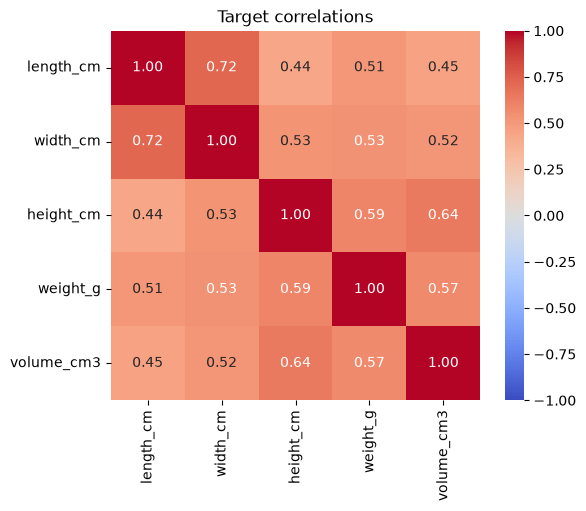

In [9]:
sns.heatmap(
    df[targets].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
    square=True
)
plt.title("Target correlations")

## Source Category
We plot the source category against the target variables (in log scale).

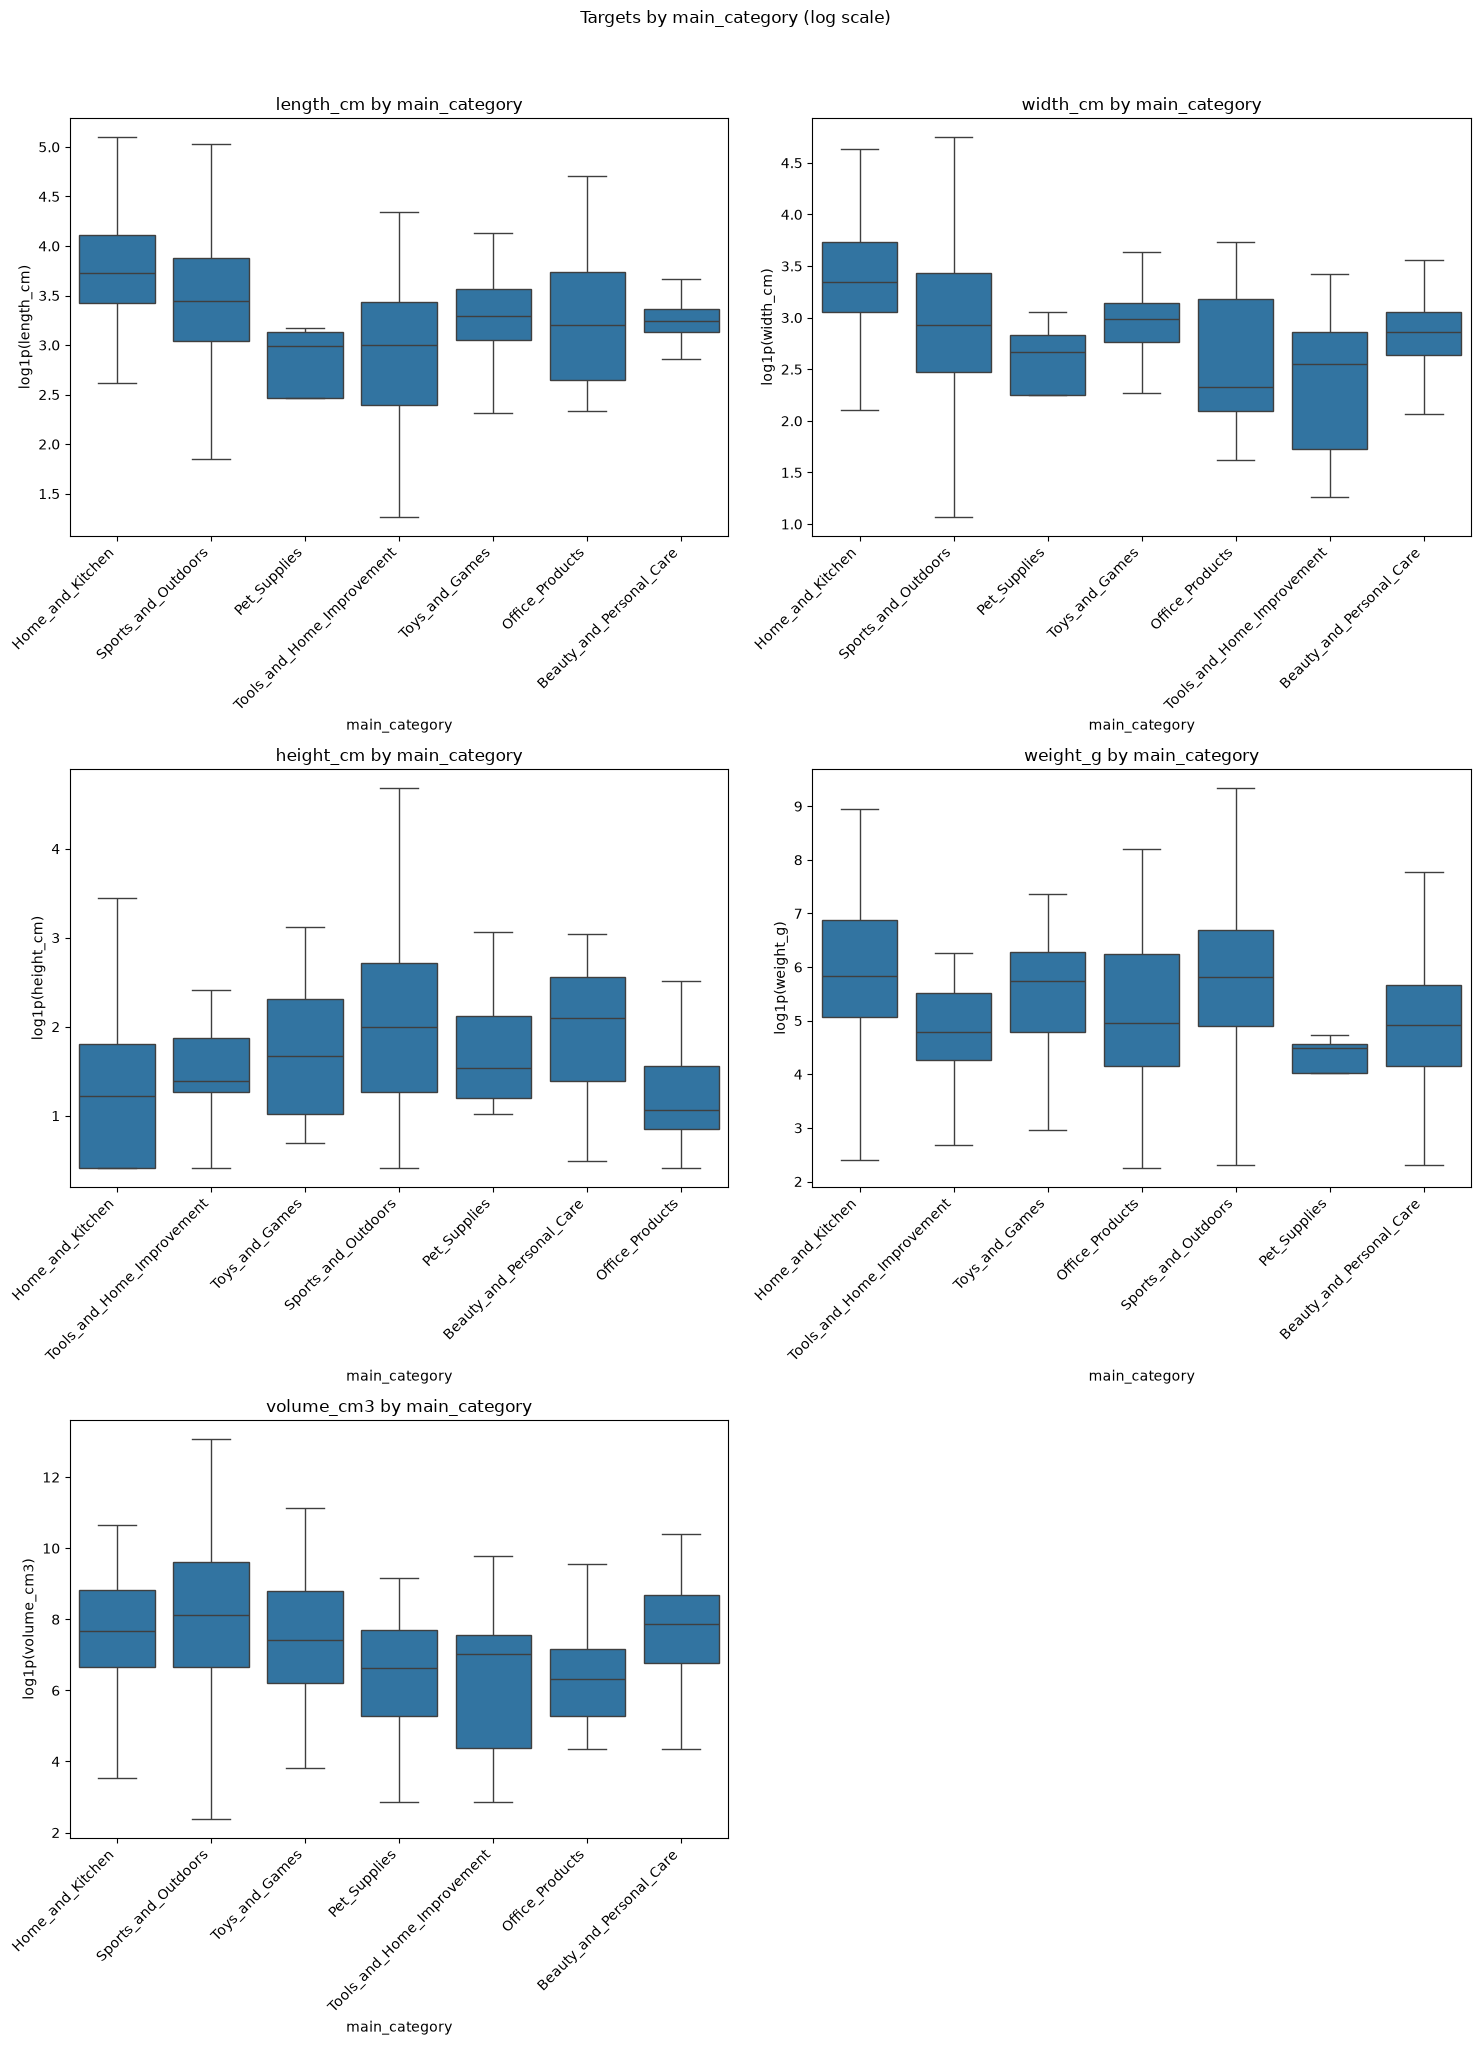

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()

for ax, col in zip(axes, targets):
    order = df.groupby("source_category")[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x="main_category", y=np.log1p(df[col]),
                order=order, ax=ax, showfliers=False)
    ax.set_xticks(ax.get_xticks())  # fix the locator first
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_ylabel(f"log1p({col})")
    ax.set_title(f"{col} by main_category")

axes[-1].set_visible(False)
plt.suptitle("Targets by main_category (log scale)", y=1.02)
plt.tight_layout()

## Numerical against dimensions
We check if the numerical variables are relevant to prediction

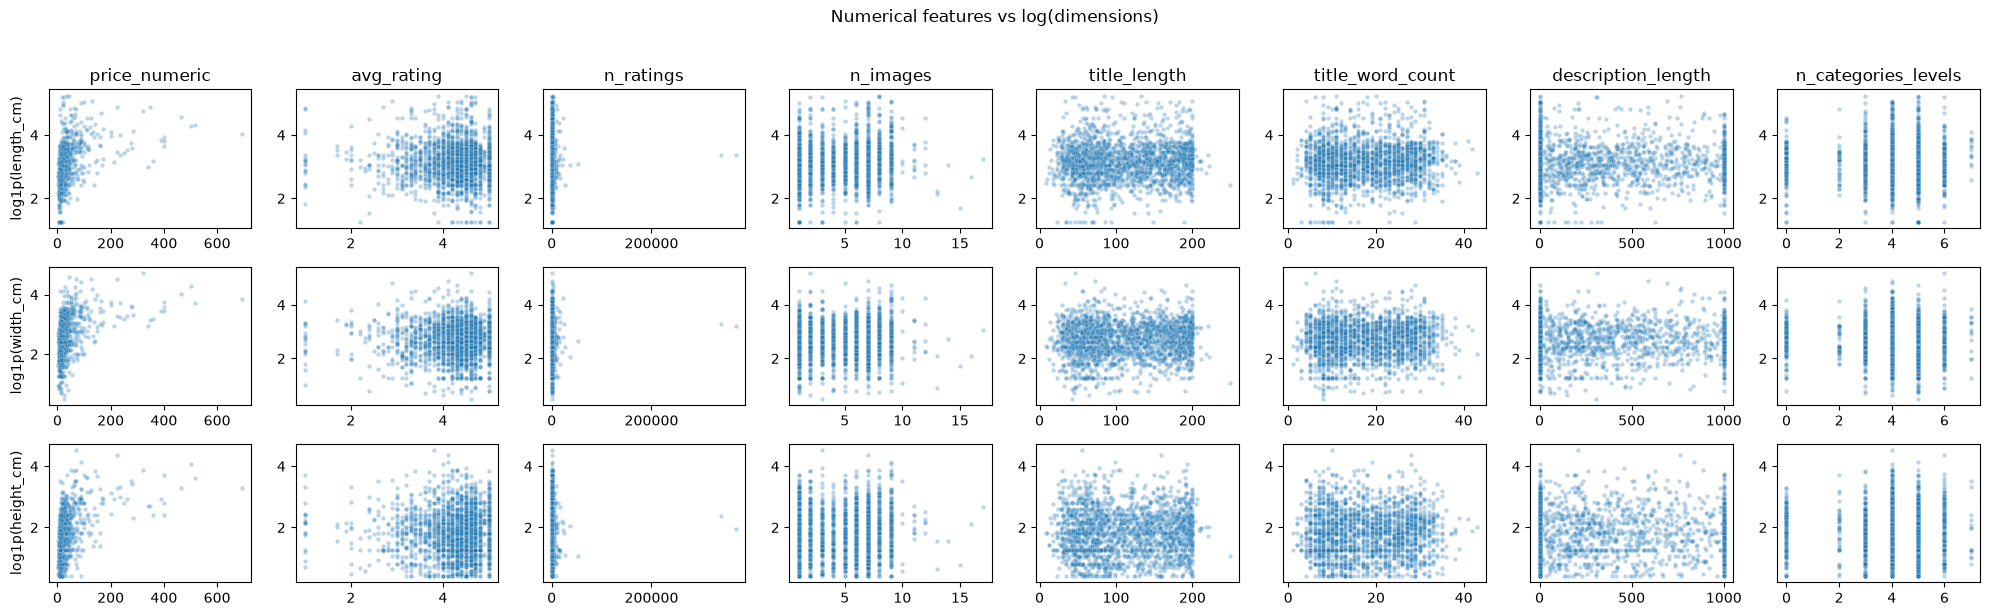

In [16]:
fig, axes = plt.subplots(3, len(features["numerical"]), figsize=(20, 6))

for i, target in enumerate(targets[:3]):
    for j, feat in enumerate(features["numerical"]):
        ax = axes[i, j]
        sns.scatterplot(data=df.sample(2000, random_state=42),
                        x=feat, y=np.log1p(df.loc[df.sample(2000, random_state=42).index, target]),
                        alpha=0.3, s=10, ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel(f"log1p({target})" if j == 0 else "")
        ax.set_title(f"{feat}" if i == 0 else "")

plt.suptitle("Numerical features vs log(dimensions)", y=1.02)
plt.tight_layout()

## Regex flags agains dimensions
Are regex variables useful for prediction? Apparently not, but they could still be useful to extract the dimensions, size and quantity of the items

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, flag in zip(axes, features["title_regex"]):
    sns.boxplot(data=df, x=flag, y=np.log1p(df["volume_cm3"]),
                showfliers=False, ax=ax)
    ax.set_title(flag)
    ax.set_xlabel("")
    ax.set_ylabel("log1p(volume_cm3)")
plt.suptitle("Regex title signals vs volume", y=1.02)
plt.tight_layout()

## Dimensions Heatmap

In [36]:
targets

['length_cm', 'width_cm', 'height_cm', 'weight_g', 'volume_cm3']

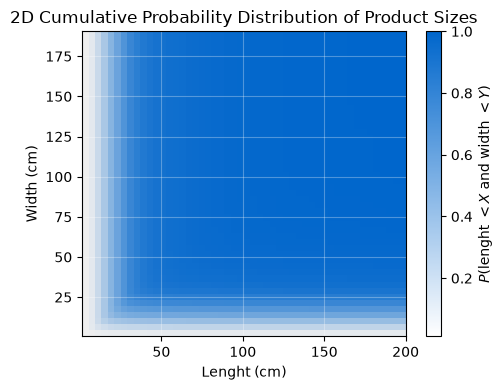

In [54]:
from matplotlib.colors import LinearSegmentedColormap

# 1. Clean data and calculate Base Area
df_clean = df[targets].dropna().copy()

x = df_clean["length_cm"]
y = df_clean["width_cm"]

H, xedges, yedges = np.histogram2d(x, y, bins=50)
H_cumsum = np.cumsum(np.cumsum(H, axis=0), axis=1)
cdf = H_cumsum / H_cumsum[-1, -1]

base_color = (0.0, 0.4, 0.8) 
colors = [(*base_color, 0.0), (*base_color, 1.0)] 
alpha_cmap = LinearSegmentedColormap.from_list("AlphaBlue", colors)

fig, ax = plt.subplots(figsize=(5, 4))

ax.set_facecolor('#f0f0f0')

mesh = ax.pcolormesh(xedges, yedges, cdf.T, cmap=alpha_cmap, shading='flat')

cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label(r'$P(\text{lenght } < X \text{ and } \text{width } < Y)$')

ax.set_title("2D Cumulative Probability Distribution of Product Sizes")
ax.set_xlabel("Lenght (cm)")
ax.set_ylabel("Width (cm)")

ax.grid(alpha=0.3, color='white')

plt.tight_layout()